In [1]:
import torch
from torch import nn
import lightning as L
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

utils

In [2]:
#将图像拆为patches
def patchify(images, patch_size=4):
    """
    将一批图片切分成 patch。

    参数：
        images:
            形状为 [B, C, H, W]

        patch_size:
            每个 patch 的边长

    返回：
        patches:
            形状为 [B, N, patch_size * patch_size * C]

            N = (H / patch_size) * (W / patch_size)
    """
    batch_size, channels, height, width = images.shape

    assert height % patch_size == 0
    assert width % patch_size == 0

    grid_height = height // patch_size
    grid_width = width // patch_size

    # [B, C, H, W]
    # ->
    # [B, C, grid_height, patch_size, grid_width, patch_size]
    patches = images.reshape(
        batch_size,
        channels,
        grid_height,
        patch_size,
        grid_width,
        patch_size,
    )

    # 把属于同一个 patch 的维度放到一起。
    #
    # [B, C, grid_height, patch_height, grid_width, patch_width]
    # ->
    # [B, grid_height, grid_width, patch_height, patch_width, C]
    patches = patches.permute(0, 2, 4, 3, 5, 1)

    # 把二维 patch 网格展平成 patch 序列。
    #
    # [B, grid_height, grid_width, patch_size, patch_size, C]
    # ->
    # [B, N, patch_size * patch_size * C]
    patches = patches.reshape(
        batch_size,
        grid_height * grid_width,
        patch_size * patch_size * channels,
    )

    return patches
#将patches组成图像
def unpatchify(patches, patch_size=4):
    """
    将 patch 序列恢复成图片。

    参数：
        patches:
            [B, N, patch_size * patch_size * C]

    返回：
        images:
            [B, C, H, W]
    """
    batch_size, num_patches, patch_dim = patches.shape

    grid_size = int(num_patches**0.5)

    assert grid_size * grid_size == num_patches
    assert patch_dim % (patch_size * patch_size) == 0

    channels = patch_dim // (patch_size * patch_size)

    # [B, N, patch_size * patch_size * C]
    # ->
    # [B, grid_height, grid_width, patch_height, patch_width, C]
    images = patches.reshape(
        batch_size,
        grid_size,
        grid_size,
        patch_size,
        patch_size,
        channels,
    )

    # [B, grid_height, grid_width, patch_height, patch_width, C]
    # ->
    # [B, C, grid_height, patch_height, grid_width, patch_width]
    images = images.permute(0, 5, 1, 3, 2, 4)

    # 拼回完整图片。
    images = images.reshape(
        batch_size,
        channels,
        grid_size * patch_size,
        grid_size * patch_size,
    )

    return images
#进行mask，返回x_visivle（encoder输入），mask（指示哪里是mask的），ids_restore指示打乱后对应原本的位置
def random_masking(x, mask_ratio=0.75):
    """
    对每张图片独立进行随机 patch 遮挡。

    参数：
        x:
            [B, N, D]

            B：batch size
            N：patch 数量
            D：每个 patch/token 的维度

        mask_ratio:
            被遮挡 patch 的比例

    返回：
        x_visible:
            保留下来的 patch
            [B, N_visible, D]

        mask:
            原始 patch 顺序下的遮挡标记
            [B, N]

            0 表示可见
            1 表示被遮挡

        ids_restore:
            用于恢复原始 patch 顺序
            [B, N]
    """
    batch_size, num_patches, embedding_dim = x.shape

    num_keep = int(num_patches * (1 - mask_ratio))

    # 每张图片生成一组独立的随机数。
    #
    # 每个随机数对应一个 patch。
    noise = torch.rand(
        batch_size,
        num_patches,
        device=x.device,
    )

    #生成随机数序列
    ids_shuffle = torch.argsort(noise, dim=1)

    # ids_restore 是 ids_shuffle 的逆排列，
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    # 取前 num_keep 个 patch 的索引。
    ids_keep = ids_shuffle[:, :num_keep]

    # 根据 ids_keep 从 x 中收集可见 patch。
    #
    # ids_keep:
    # [B, N_visible]
    #
    # 扩展后：
    # [B, N_visible, D]
    ids_keep_expanded = ids_keep.unsqueeze(-1).expand(
        -1,
        -1,
        embedding_dim,
    )

    x_visible = torch.gather(
        x,
        dim=1,
        index=ids_keep_expanded,
    )

    # 先在“打乱后的顺序”下创建 mask。
    #
    # 前 num_keep 个位置是可见 patch，所以设置为 0。
    # 剩余位置是被遮挡 patch，所以保持为 1。
    mask = torch.ones(
        batch_size,
        num_patches,
        device=x.device,
    )

    mask[:, :num_keep] = 0

    # 把 mask 恢复到图片原本的 patch 顺序。
    mask = torch.gather(
        mask,
        dim=1,
        index=ids_restore,
    )

    return x_visible, mask, ids_restore

data

In [3]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.CIFAR10(
    root=".",
    train=True,
    transform=train_transform,
    download=True,
)
test_dataset = datasets.CIFAR10(
    root=".",
    train=False,
    transform=test_transform,
    download=True,
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

model

In [4]:
#encoder返回latent（encoder输出）, mask（mask位置,计算loss）, ids_restore（打乱反顺序）
class MAEEncoder(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        encoder_dim=128,
        encoder_depth=4,
        num_heads=4,
        mlp_dim=256,
    ):
        super().__init__()

        assert image_size % patch_size == 0
        assert encoder_dim % num_heads == 0

        self.patch_size = patch_size

        patches_per_side = image_size // patch_size
        self.num_patches = patches_per_side**2

        # 每个 patch 展平后的像素数量。
        self.patch_dim = (
            patch_size
            * patch_size
            * in_channels
        )

        # [B, 64, 48] -> [B, 64, 128]
        self.patch_embedding = nn.Linear(
            self.patch_dim,
            encoder_dim,
        )

        # 每个 patch 位置都有一个可学习的位置向量。
        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                self.num_patches,
                encoder_dim,
            )
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=encoder_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=encoder_depth,
            norm=nn.LayerNorm(encoder_dim),
        )

        self.initialize_weights()

    def initialize_weights(self):
        #位置编码矩阵被初始化为均值为0，标准差为0.02的随机小数。
        nn.init.trunc_normal_(
            self.position_embedding,
            std=0.02,
        )

        # xavier初始化 Patch Embedding。
        nn.init.xavier_uniform_(
            self.patch_embedding.weight
        )

        if self.patch_embedding.bias is not None:
            nn.init.zeros_(
                self.patch_embedding.bias
            )

    def forward(self, images, mask_ratio=0.75):
        # 1. 图片切成 patch。
        #
        # [B, 3, 32, 32]
        # ->
        # [B, 64, 48]
        patches = patchify(
            images,
            patch_size=self.patch_size,
        )

        # 2. Patch Embedding。
        #
        # [B, 64, 48]
        # ->
        # [B, 64, 128]
        tokens = self.patch_embedding(patches)

        # 3. 添加位置编码。
        tokens = (
            tokens
            + self.position_embedding
        )

        # 4. 随机遮挡。
        #
        # [B, 64, 128]
        # ->
        # [B, 16, 128]
        visible_tokens, mask, ids_restore = random_masking(
            tokens,
            mask_ratio=mask_ratio,
        )

        # 5. Encoder 只处理可见 token。
        latent = self.transformer(
            visible_tokens
        )

        return latent, mask, ids_restore
#decoder返回prediction
class MAEDecoder(nn.Module):
    def __init__(
        self,
        num_patches=64,
        patch_dim=48,
        encoder_dim=128,
        decoder_dim=64,
        decoder_depth=4,
        num_heads=4,
        mlp_dim=128,
    ):
        super().__init__()

        assert decoder_dim % num_heads == 0

        self.num_patches = num_patches
        self.decoder_dim = decoder_dim

        # Encoder 和 Decoder 可以使用不同的特征维度。
        #
        # [B, 16, 128]
        # ->
        # [B, 16, 64]
        self.encoder_to_decoder = nn.Linear(
            encoder_dim,
            decoder_dim,
        )

        # 所有被遮挡位置共享同一个可学习的 mask token。
        self.mask_token = nn.Parameter(
            torch.zeros(1, 1, decoder_dim)
        )

        # Decoder 需要自己的位置编码，因为 decoder_dim
        # 可能与 encoder_dim 不同。
        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                num_patches,
                decoder_dim,
            )
        )

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=0.0,
            activation="gelu",
            batch_first=True,#batch维放第一个
            norm_first=True,#prenorm
        )

        # MAE 的 Decoder 本质上是较浅的 Transformer Encoder。
        self.transformer = nn.TransformerEncoder(
            encoder_layer=decoder_layer,
            num_layers=decoder_depth,
            norm=nn.LayerNorm(decoder_dim),
        )

        # 将 Decoder 特征映射回 patch 像素。
        #
        # decoder_dim=64
        # patch_dim=4*4*3=48
        self.prediction_head = nn.Linear(
            decoder_dim,
            patch_dim,
        )

        self.initialize_weights()

    def initialize_weights(self):
        nn.init.trunc_normal_(
            self.mask_token,
            std=0.02,
        )

        nn.init.trunc_normal_(
            self.position_embedding,
            std=0.02,
        )

        nn.init.xavier_uniform_(
            self.encoder_to_decoder.weight
        )
        nn.init.zeros_(
            self.encoder_to_decoder.bias
        )

        nn.init.xavier_uniform_(
            self.prediction_head.weight
        )
        nn.init.zeros_(
            self.prediction_head.bias
        )

    def forward(self, latent, ids_restore):
        """
        参数：
            latent:
                Encoder 输出
                [B, N_visible, encoder_dim]

            ids_restore:
                用于恢复原始 patch 顺序
                [B, N]

        返回：
            prediction:
                所有 patch 的预测像素
                [B, N, patch_dim]
        """
        batch_size, num_visible, _ = latent.shape

        # 1. 映射到 Decoder 特征维度。
        #
        # [B, 16, 128]
        # ->
        # [B, 16, 64]
        x = self.encoder_to_decoder(latent)

        # 2. 计算需要补多少个 mask token。
        #
        # 64 - 16 = 48
        num_masked = (
            self.num_patches
            - num_visible
        )

        # [1, 1, 64]
        # ->
        # [B, 48, 64]
        mask_tokens = self.mask_token.expand(
            batch_size,
            num_masked,
            -1,
        )

        # 3. 先把 mask token 接到可见 token 后面。
        #
        # [B, 16, 64] + [B, 48, 64]
        # ->
        # [B, 64, 64]
        x = torch.cat(
            [x, mask_tokens],
            dim=1,
        )

        # 4. 使用 ids_restore 恢复原始 patch 顺序。
        restore_index = ids_restore.unsqueeze(-1).expand(
            -1,
            -1,
            self.decoder_dim,
        )

        x = torch.gather(
            x,
            dim=1,
            index=restore_index,
        )

        # 5. 添加 Decoder 位置编码。
        x = (
            x
            + self.position_embedding
        )

        # 6. 较浅的 Transformer Decoder。
        x = self.transformer(x)

        # 7. 为每个 patch 预测 48 个像素值。
        #
        # [B, 64, 64]
        # ->
        # [B, 64, 48]
        prediction = self.prediction_head(x)

        return prediction
class MaskedAutoencoder(L.LightningModule):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        mask_ratio=0.75,
        encoder_dim=128,
        encoder_depth=4,
        encoder_heads=4,
        encoder_mlp_dim=256,
        decoder_dim=64,
        decoder_depth=4,
        decoder_heads=4,
        decoder_mlp_dim=128,
        learning_rate=3e-4,
        weight_decay=0.05,
    ):
        super().__init__()

        # Lightning 会把这些参数保存到 checkpoint。
        self.save_hyperparameters()

        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

        num_patches = (
            image_size // patch_size
        ) ** 2

        patch_dim = (
            patch_size
            * patch_size
            * 3
        )

        self.encoder = MAEEncoder(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=3,
            encoder_dim=encoder_dim,
            encoder_depth=encoder_depth,
            num_heads=encoder_heads,
            mlp_dim=encoder_mlp_dim,
        )

        self.decoder = MAEDecoder(
            num_patches=num_patches,
            patch_dim=patch_dim,
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim,
            decoder_depth=decoder_depth,
            num_heads=decoder_heads,
            mlp_dim=decoder_mlp_dim,
        )

    def forward(self, images):
        """
        一次完整的 MAE 前向传播。

        参数：
            images:
                [B, 3, 32, 32]

        返回：
            loss:
                被遮挡 patch 的重建损失

            prediction:
                [B, 64, 48]

            mask:
                [B, 64]
        """

        # Encoder 只处理可见 patch。
        latent, mask, ids_restore = self.encoder(
            images,
            mask_ratio=self.mask_ratio,
        )

        # Decoder 预测全部 patch。
        prediction = self.decoder(
            latent,
            ids_restore,
        )

        # 只计算被遮挡 patch 的 MSE。
        loss = reconstruction_loss(
            images,
            prediction,
            mask,
            patch_size=self.patch_size,
        )

        return loss, prediction, mask

    def training_step(self, batch, batch_idx):
        # CIFAR-10 返回 (images, labels)。
        # MAE 不使用类别标签。
        images, _ = batch

        loss, prediction, mask = self(images)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,#写进训练进度条
            batch_size=images.size(0),
        )

        return loss


    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )

        return optimizer

loss

In [5]:
def reconstruction_loss(
    images,
    prediction,
    mask,
    patch_size=4,
):
    target = patchify(
        images,
        patch_size=patch_size,
    )

    loss = (
        prediction
        - target
    ) ** 2

    # 每个 patch 内部取平均。
    loss = loss.mean(dim=-1)

    # 只计算被遮挡 patch。
    loss = (
        loss * mask
    ).sum() / mask.sum()

    return loss

train

In [ ]:
def train_mae(
        model,
        train_loader, 
        max_epochs=100,
        ):
    logger = TensorBoardLogger(
        save_dir="./logs",
        name="mae_cifar10",
    )

    # 根据每个 epoch 的训练损失保存最佳模型。
    checkpoint_callback = ModelCheckpoint(
        dirpath="./checkpoints",
        filename="mae",
        monitor="train_loss",
        mode="min",
        save_weights_only=True
    )

    # GPU 使用混合精度，CPU 使用普通 float32。
    if torch.cuda.is_available():
        precision = "16-mixed"
    else:
        precision = "32-true"

    trainer = L.Trainer(
        max_epochs=max_epochs,
        accelerator=("gpu"if torch.cuda.is_available()else "cpu"),
        devices=1,
        precision=precision,
        logger=logger,
        callbacks=[checkpoint_callback],
        gradient_clip_val=1.0,
    )

    # 使用 CIFAR-10 训练集进行 MAE 预训练。
    trainer.fit(
        model=model,
        train_dataloaders=train_loader,
    )

    print(
        "最佳模型：",
        checkpoint_callback.best_model_path,
    )

    return trainer
model = MaskedAutoencoder(
    image_size=32,
    patch_size=4,
    mask_ratio=0.75,

    encoder_dim=192,
    encoder_depth=6,
    encoder_heads=4,
    encoder_mlp_dim=768,

    decoder_dim=128,
    decoder_depth=4,
    decoder_heads=4,
    decoder_mlp_dim=512,

    learning_rate=3e-4,
    weight_decay=0.05,
)
trainer = train_mae(
    model=model,
    train_loader=train_loader,
    max_epochs=1,
)

test

C:\Users\58473\AppData\Local\Temp\ipykernel_22124\1592861024.py:55: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
C:\Users\58473\AppData\Local\Temp\ipykernel_22124\1592861024.py:175: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


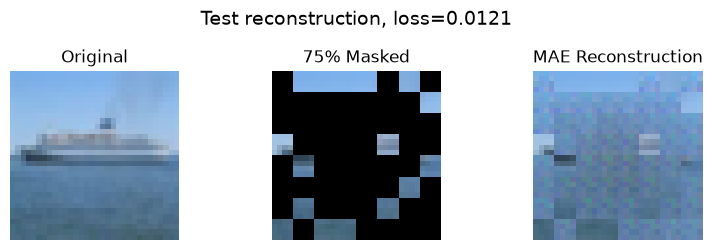

In [6]:
@torch.no_grad()
def visualize_reconstruction(
    model,
    test_dataset,
    num_images=6,
):
    """
    从 CIFAR-10 测试集随机抽取图片，显示：

    原图 | 遮挡图 | MAE 重建图
    """

    # 切换到评估模式。
    model.eval()

    # 获取模型所在设备。
    device = next(model.parameters()).device

    # 随机抽取测试集索引。
    indices = torch.randperm(
        len(test_dataset)
    )[:num_images]


    # 取出图片，忽略 CIFAR-10 标签。
    images = torch.stack([
        test_dataset[index.item()][0]
        for index in indices
    ])

    images = images.to(device)

    # 模型会在这里生成一组新的随机 mask。
    loss, prediction, mask = model(images)

    # 原始图片转换为 patch。
    #
    # [B, 3, 32, 32]
    # ->
    # [B, 64, 48]
    target_patches = patchify(
        images,
        patch_size=model.patch_size,
    )

    patch_mask = mask.unsqueeze(-1)

    # 可见 patch 保持原值，
    # 被遮挡 patch 设置成 0。
    masked_patches = (
        target_patches
        * (1 - patch_mask)
    )

    # 可见位置使用原始 patch，
    # 遮挡位置使用模型预测 patch。
    reconstructed_patches = (
        target_patches
        * (1 - patch_mask)
        + prediction
        * patch_mask
    )

    # 将 patch 序列重新拼接成图片。
    masked_images = unpatchify(
        masked_patches,
        patch_size=model.patch_size,
    )

    reconstructed_images = unpatchify(
        reconstructed_patches,
        patch_size=model.patch_size,
    )

    # 模型输出不一定严格位于 [0,1]，
    # 显示前进行截断。
    reconstructed_images = (
        reconstructed_images.clamp(0, 1)
    )

    images = images.cpu()
    masked_images = masked_images.cpu()
    reconstructed_images = reconstructed_images.cpu()

    figure, axes = plt.subplots(
        num_images,
        3,
        figsize=(8, 2.5 * num_images),
    )

    # num_images=1 时，保持二维索引形式。
    if num_images == 1:
        axes = axes.reshape(1, 3)

    for row in range(num_images):
        original = images[row].permute(1, 2, 0)
        masked = masked_images[row].permute(1, 2, 0)
        reconstructed = reconstructed_images[row].permute(
            1, 2, 0
        )

        axes[row, 0].imshow(original)
        axes[row, 0].set_title("Original")

        axes[row, 1].imshow(masked)
        axes[row, 1].set_title("75% Masked")

        axes[row, 2].imshow(reconstructed)
        axes[row, 2].set_title("MAE Reconstruction")

        for column in range(3):
            axes[row, column].axis("off")

    figure.suptitle(
        f"Test reconstruction, loss={loss.item():.4f}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()
best_checkpoint_path = ('./checkpoints/mae.ckpt')
best_model = MaskedAutoencoder.load_from_checkpoint(best_checkpoint_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(device)
visualize_reconstruction(
    model=best_model,
    test_dataset=test_dataset,
    num_images=1,
)